In [ ]:
import pandas as pd
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

print("Loading the massive balanced dataset... (This might take a minute)")

df = pd.read_csv('../data/processed/cicids2017_balanced.csv')


X = df.drop(columns=['Attack Type'])
y = df['Attack Type']


encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)


print("Splitting data into 80% Training and 20% Testing...")
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.20, random_state=42)

print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")

Loading the massive balanced dataset... (This might take a minute)
Splitting data into 80% Training and 20% Testing...
Training Data Shape: (2636045, 52)
Testing Data Shape: (659012, 52)


In [ ]:

print("Training Random Forest... (Grab a coffee, this will take time!)")
start_time = time.time()
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_time = time.time() - start_time


rf_preds = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)
print(f"✅ Random Forest Complete! Accuracy: {rf_acc:.4f} (Took {rf_time/60:.2f} minutes)")


print("\nTraining XGBoost... (Almost there!)")
start_time = time.time()
xgb_model = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)
xgb_time = time.time() - start_time


xgb_preds = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_preds)
print(f"✅ XGBoost Complete! Accuracy: {xgb_acc:.4f} (Took {xgb_time/60:.2f} minutes)")

Training Random Forest... (Grab a coffee, this will take time!)
✅ Random Forest Complete! Accuracy: 0.9988 (Took 14.83 minutes)

Training XGBoost... (Almost there!)
✅ XGBoost Complete! Accuracy: 0.9990 (Took 4.13 minutes)


--- XGBoost Detailed Performance Report ---
                precision    recall  f1-score   support

          Bots       0.99      1.00      1.00     40115
   Brute Force       1.00      1.00      1.00     39965
          DDoS       1.00      1.00      1.00     39777
           DoS       1.00      1.00      1.00     40124
Normal Traffic       1.00      1.00      1.00    418938
 Port Scanning       0.99      1.00      1.00     40035
   Web Attacks       1.00      1.00      1.00     40058

      accuracy                           1.00    659012
     macro avg       1.00      1.00      1.00    659012
  weighted avg       1.00      1.00      1.00    659012



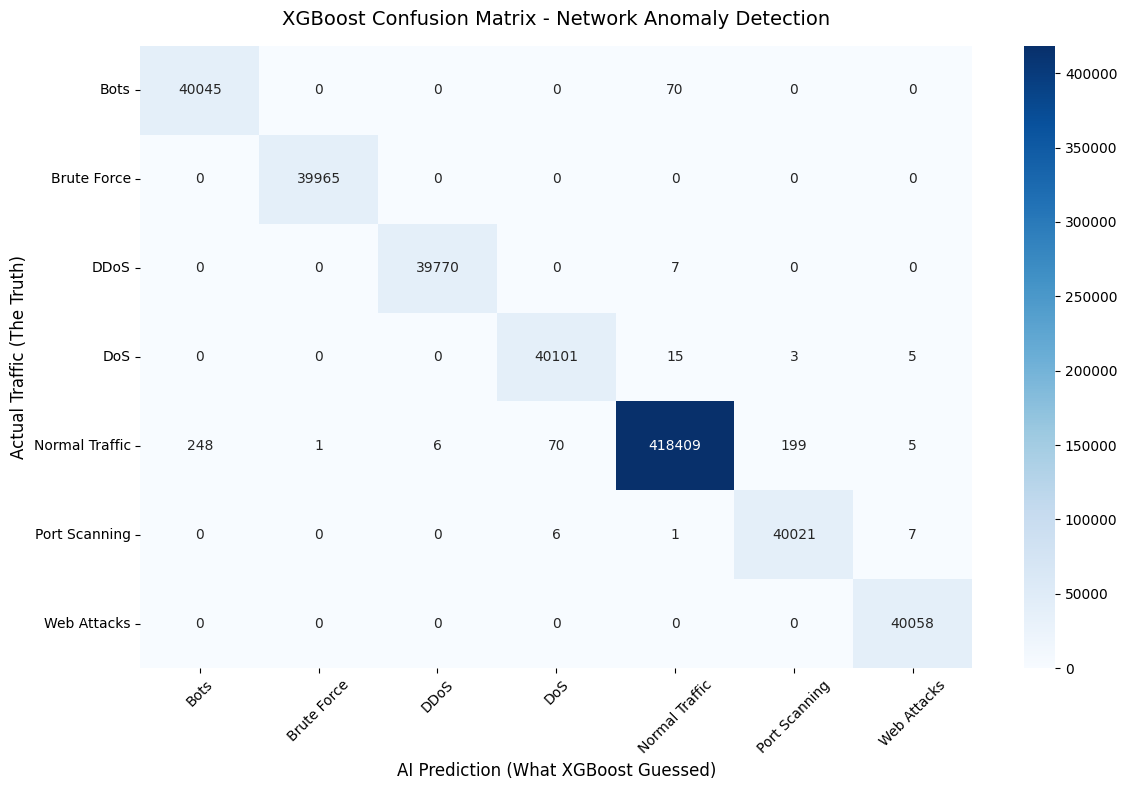

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix


class_names = encoder.classes_


print("--- XGBoost Detailed Performance Report ---")
print(classification_report(y_test, xgb_preds, target_names=class_names))


plt.figure(figsize=(12, 8))
xgb_cm = confusion_matrix(y_test, xgb_preds)


sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)

plt.title('XGBoost Confusion Matrix - Network Anomaly Detection', fontsize=14, pad=15)
plt.ylabel('Actual Traffic (The Truth)', fontsize=12)
plt.xlabel('AI Prediction (What XGBoost Guessed)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

print("Extracting a 10% stratified sample for safe hyperparameter tuning...")

X_tune, _, y_tune, _ = train_test_split(X_train, y_train, train_size=0.10, random_state=42, stratify=y_train)


param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200]
}


print("Starting the Randomized Search... (This should take about 3-5 minutes)")
xgb_tuner = XGBClassifier(random_state=42, n_jobs=-1, eval_metric='mlogloss')


random_search = RandomizedSearchCV(estimator=xgb_tuner, param_distributions=param_grid, 
                                   n_iter=5, cv=3, verbose=2, random_state=42, n_jobs=-1)


random_search.fit(X_tune, y_tune)


print(f"\n✅ Optimization Complete!")
print(f"Best Parameters Found: {random_search.best_params_}")

Extracting a 10% stratified sample for safe hyperparameter tuning...
Starting the Randomized Search... (This should take about 3-5 minutes)
Fitting 3 folds for each of 5 candidates, totalling 15 fits

✅ Optimization Complete!
Best Parameters Found: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1}
